# Analysing Pharma Sales Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('salesdaily.csv')
df

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.00,3.670,3.40,32.40,7.0,0.0,0.0,2.00,2014,1,248,Thursday
1,1/3/2014,8.00,4.000,4.40,50.60,16.0,0.0,20.0,4.00,2014,1,276,Friday
2,1/4/2014,2.00,1.000,6.50,61.85,10.0,0.0,9.0,1.00,2014,1,276,Saturday
3,1/5/2014,4.00,3.000,7.00,41.10,8.0,0.0,3.0,0.00,2014,1,276,Sunday
4,1/6/2014,5.00,1.000,4.50,21.70,16.0,2.0,6.0,2.00,2014,1,276,Monday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2101,10/4/2019,7.34,5.683,2.25,22.45,13.0,0.0,1.0,1.00,2019,10,276,Friday
2102,10/5/2019,3.84,5.010,6.00,25.40,7.0,0.0,0.0,0.33,2019,10,276,Saturday
2103,10/6/2019,4.00,11.690,2.00,34.60,6.0,0.0,5.0,4.20,2019,10,276,Sunday
2104,10/7/2019,7.34,4.507,3.00,50.80,6.0,0.0,10.0,1.00,2019,10,276,Monday


In [6]:
df['datum'] = pd.to_datetime(df['datum'])
drug_cols = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

In [8]:
total_sales = df[drug_cols].sum().sort_values(ascending=False)
print("Total sales for each drug category:")
print(total_sales)
print("\n")

Total sales for each drug category:
N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
M01AB    10600.937083
M01AE     8204.618646
N02BA     8172.209000
R06       6107.817500
N05C      1249.958333
dtype: float64




Text(0, 0.5, 'Total Sales')

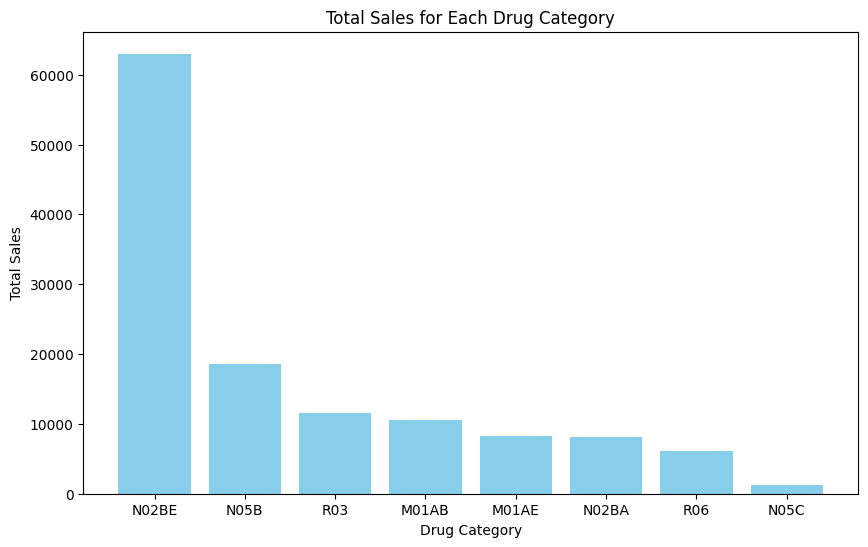

In [12]:
plt.figure(figsize=(10, 6))
plt.bar(total_sales.index, total_sales.values, color='skyblue')
plt.title('Total Sales for Each Drug Category')
plt.xlabel('Drug Category')
plt.ylabel('Total Sales')

In [19]:
def get_top_3(year, month):
    filtered_df = df[(df['datum'].dt.year == year) & (df['datum'].dt.month == month)]
    top_3 = filtered_df[drug_cols].sum().sort_values(ascending=False).head(3)
    return top_3
print("Top 3 drug categories for January 2015:")
print(get_top_3(2015, 1))
print("\nTop 3 drug categories for Juli 2016:")
print(get_top_3(2016, 7))
print("\nTop 3 drug categories for September 2017:")
print(get_top_3(2017, 9))

Top 3 drug categories for January 2015:
N02BE    1044.24
N05B      463.00
R03       177.25
dtype: float64

Top 3 drug categories for Juli 2016:
N02BE    652.362000
N05B     240.000000
M01AB    194.528333
dtype: float64

Top 3 drug categories for September 2017:
N02BE    863.75
N05B     223.00
R03      139.00
dtype: float64


In [21]:
df_2017 = df[df['datum'].dt.year == 2017]
top_2017 = df_2017[drug_cols].sum().idxmax()
top_2017_sales = df_2017[drug_cols].sum().max()
print(f"\nThe drug category with the highest sales in 2017 is {top_2017} with total sales of {top_2017_sales}.")


The drug category with the highest sales in 2017 is N02BE with total sales of 9258.80483333.


In [23]:
avg_daily_sales = df[drug_cols].mean().sort_values(ascending=False)
print("\nAverage daily sales for each drug category:")
print(avg_daily_sales)


Average daily sales for each drug category:
N02BE    29.917095
N05B      8.853627
R03       5.512262
M01AB     5.033683
M01AE     3.895830
N02BA     3.880441
R06       2.900198
N05C      0.593522
dtype: float64


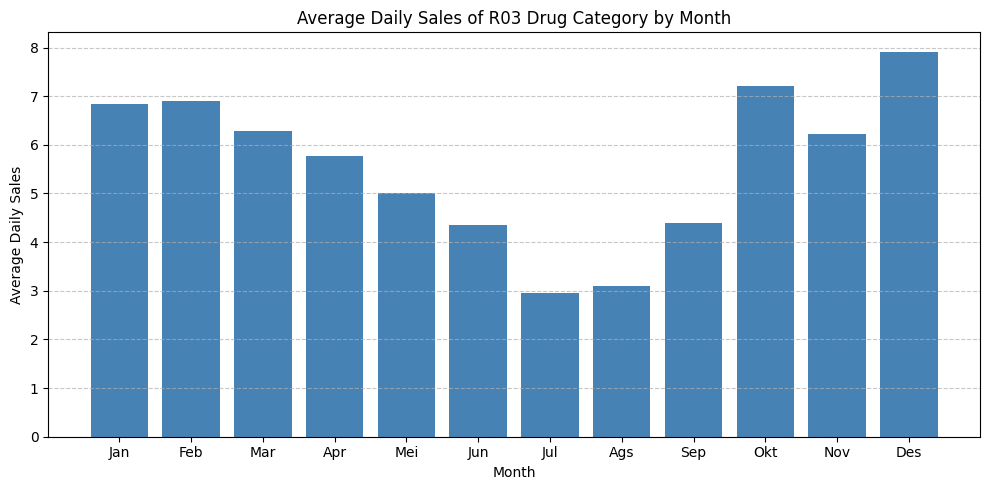

In [29]:
r03_monthly = df.groupby('Month')['R03'].mean()

plt.figure(figsize=(10, 5))
plt.bar(r03_monthly.index, r03_monthly.values, color='steelblue')

plt.title('Average Daily Sales of R03 Drug Category by Month')
plt.xlabel('Month')
plt.ylabel('Average Daily Sales')

bulan_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 
                'Jul', 'Ags', 'Sep', 'Okt', 'Nov', 'Des']
plt.xticks(ticks=r03_monthly.index, labels=bulan_labels)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()